# Stage 2+3: Preprocessing + Attention U-Net untuk Segmentasi Soft Exudate

**Pipeline lengkap dalam satu notebook:**
1. Load raw image
2. Predict OD mask → Mask R-CNN (dari Stage 1)
3. Predict HE mask → U-Net (dari Stage 1B)
4. Blackout area OD & HE
5. CLAHE pada green channel
6. Train Attention U-Net untuk segmentasi Soft Exudate
7. Evaluasi: IoU, Sensitivity, Specificity

## 1. Import & Setup

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import segmentation_models_pytorch as smp

import numpy as np
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from pathlib import Path
import time
import json

print(f"PyTorch  : {torch.__version__}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device   : {DEVICE}")

PyTorch  : 2.10.0
Device   : mps


## 2. Path Konfigurasi

In [41]:
BASE_DIR = Path(".")

ORIG_TRAIN = BASE_DIR / "1. Original Images" / "a. Training Set"
ORIG_TEST  = BASE_DIR / "1. Original Images" / "b. Testing Set"

GT_SE_TRAIN = BASE_DIR / "2. All Segmentation Groundtruths" / "a. Training Set" / "4. Soft Exudates"
GT_SE_TEST  = BASE_DIR / "2. All Segmentation Groundtruths" / "b. Testing Set"  / "4. Soft Exudates"

SE_SUFFIX = "_SE.tif"
IMG_SIZE = 512

# Paths ke model Stage 1
OD_MODEL_PATH = BASE_DIR / "runs" / "mask_rcnn_od" / "best.pt"
HE_MODEL_PATH = BASE_DIR / "runs" / "unet_he" / "best.pt"

print("Path konfigurasi OK")
print(f"  Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"  OD model     : Mask R-CNN -> {OD_MODEL_PATH.exists()}")
print(f"  HE model     : U-Net      -> {HE_MODEL_PATH.exists()}")

Path konfigurasi OK
  Image size   : 512x512
  OD model     : Mask R-CNN -> True
  HE model     : U-Net      -> True


## 3. Load Pretrained Models (OD & HE)

In [42]:
# OD: Mask R-CNN di CPU (RoI ops tidak stabil di MPS)
MRCNN_DEVICE = torch.device("cpu")

def load_od_model(model_path, device):
    model = maskrcnn_resnet50_fpn_v2(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, 2)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    return model

# HE: U-Net di MPS/CUDA
def load_he_model(model_path, device):
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    )
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    return model

od_model = load_od_model(OD_MODEL_PATH, MRCNN_DEVICE)
he_model = load_he_model(HE_MODEL_PATH, DEVICE)

print(f"OD model (Mask R-CNN) loaded -> {MRCNN_DEVICE}")
print(f"HE model (U-Net) loaded -> {DEVICE}")

OD model (Mask R-CNN) loaded -> cpu
HE model (U-Net) loaded -> mps


## 4. Preprocessing Functions

In [43]:
HE_MEAN = np.array([0.485, 0.456, 0.406])
HE_STD  = np.array([0.229, 0.224, 0.225])

@torch.no_grad()
def predict_od_mask(model, image_rgb, img_size=512, conf_threshold=0.5):
    """Predict OD mask (Mask R-CNN, CPU)."""
    resized = cv2.resize(image_rgb, (img_size, img_size))
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.to(MRCNN_DEVICE)
    pred = model([tensor])[0]
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    if len(pred["scores"]) > 0:
        keep = pred["scores"] >= conf_threshold
        if keep.any():
            pred_masks = pred["masks"][keep] > 0.5
            mask = pred_masks.squeeze(1).any(dim=0).cpu().numpy().astype(np.uint8)
    return mask

@torch.no_grad()
def predict_he_mask(model, image_rgb, img_size=512, threshold=0.5):
    """Predict HE mask (U-Net, MPS/CUDA)."""
    resized = cv2.resize(image_rgb, (img_size, img_size))
    normalized = (resized.astype(np.float32) / 255.0 - HE_MEAN) / HE_STD
    tensor = torch.from_numpy(normalized).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
    logits = model(tensor)
    mask = (torch.sigmoid(logits) > threshold).squeeze().cpu().numpy().astype(np.uint8)
    return mask

def apply_blackout(image_rgb, od_mask, he_mask):
    """Blackout area OD dan HE."""
    result = image_rgb.copy()
    result[od_mask > 0] = 0
    result[he_mask > 0] = 0
    return result

def apply_clahe_green(image_rgb, clip_limit=2.0, tile_size=(8, 8)):
    """Apply CLAHE pada green channel."""
    green = image_rgb[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(green)

def preprocess_image(image_rgb, od_model, he_model, img_size=512):
    """Full pipeline: Predict OD+HE -> Blackout -> CLAHE green."""
    resized = cv2.resize(image_rgb, (img_size, img_size))
    od_mask = predict_od_mask(od_model, image_rgb, img_size)
    he_mask = predict_he_mask(he_model, image_rgb, img_size)
    blacked = apply_blackout(resized, od_mask, he_mask)
    clahe_green = apply_clahe_green(blacked)
    result = np.stack([clahe_green, clahe_green, clahe_green], axis=-1)
    return result, od_mask, he_mask

print("Preprocessing functions OK")

Preprocessing functions OK


## 5. Visualisasi Preprocessing (Sanity Check)

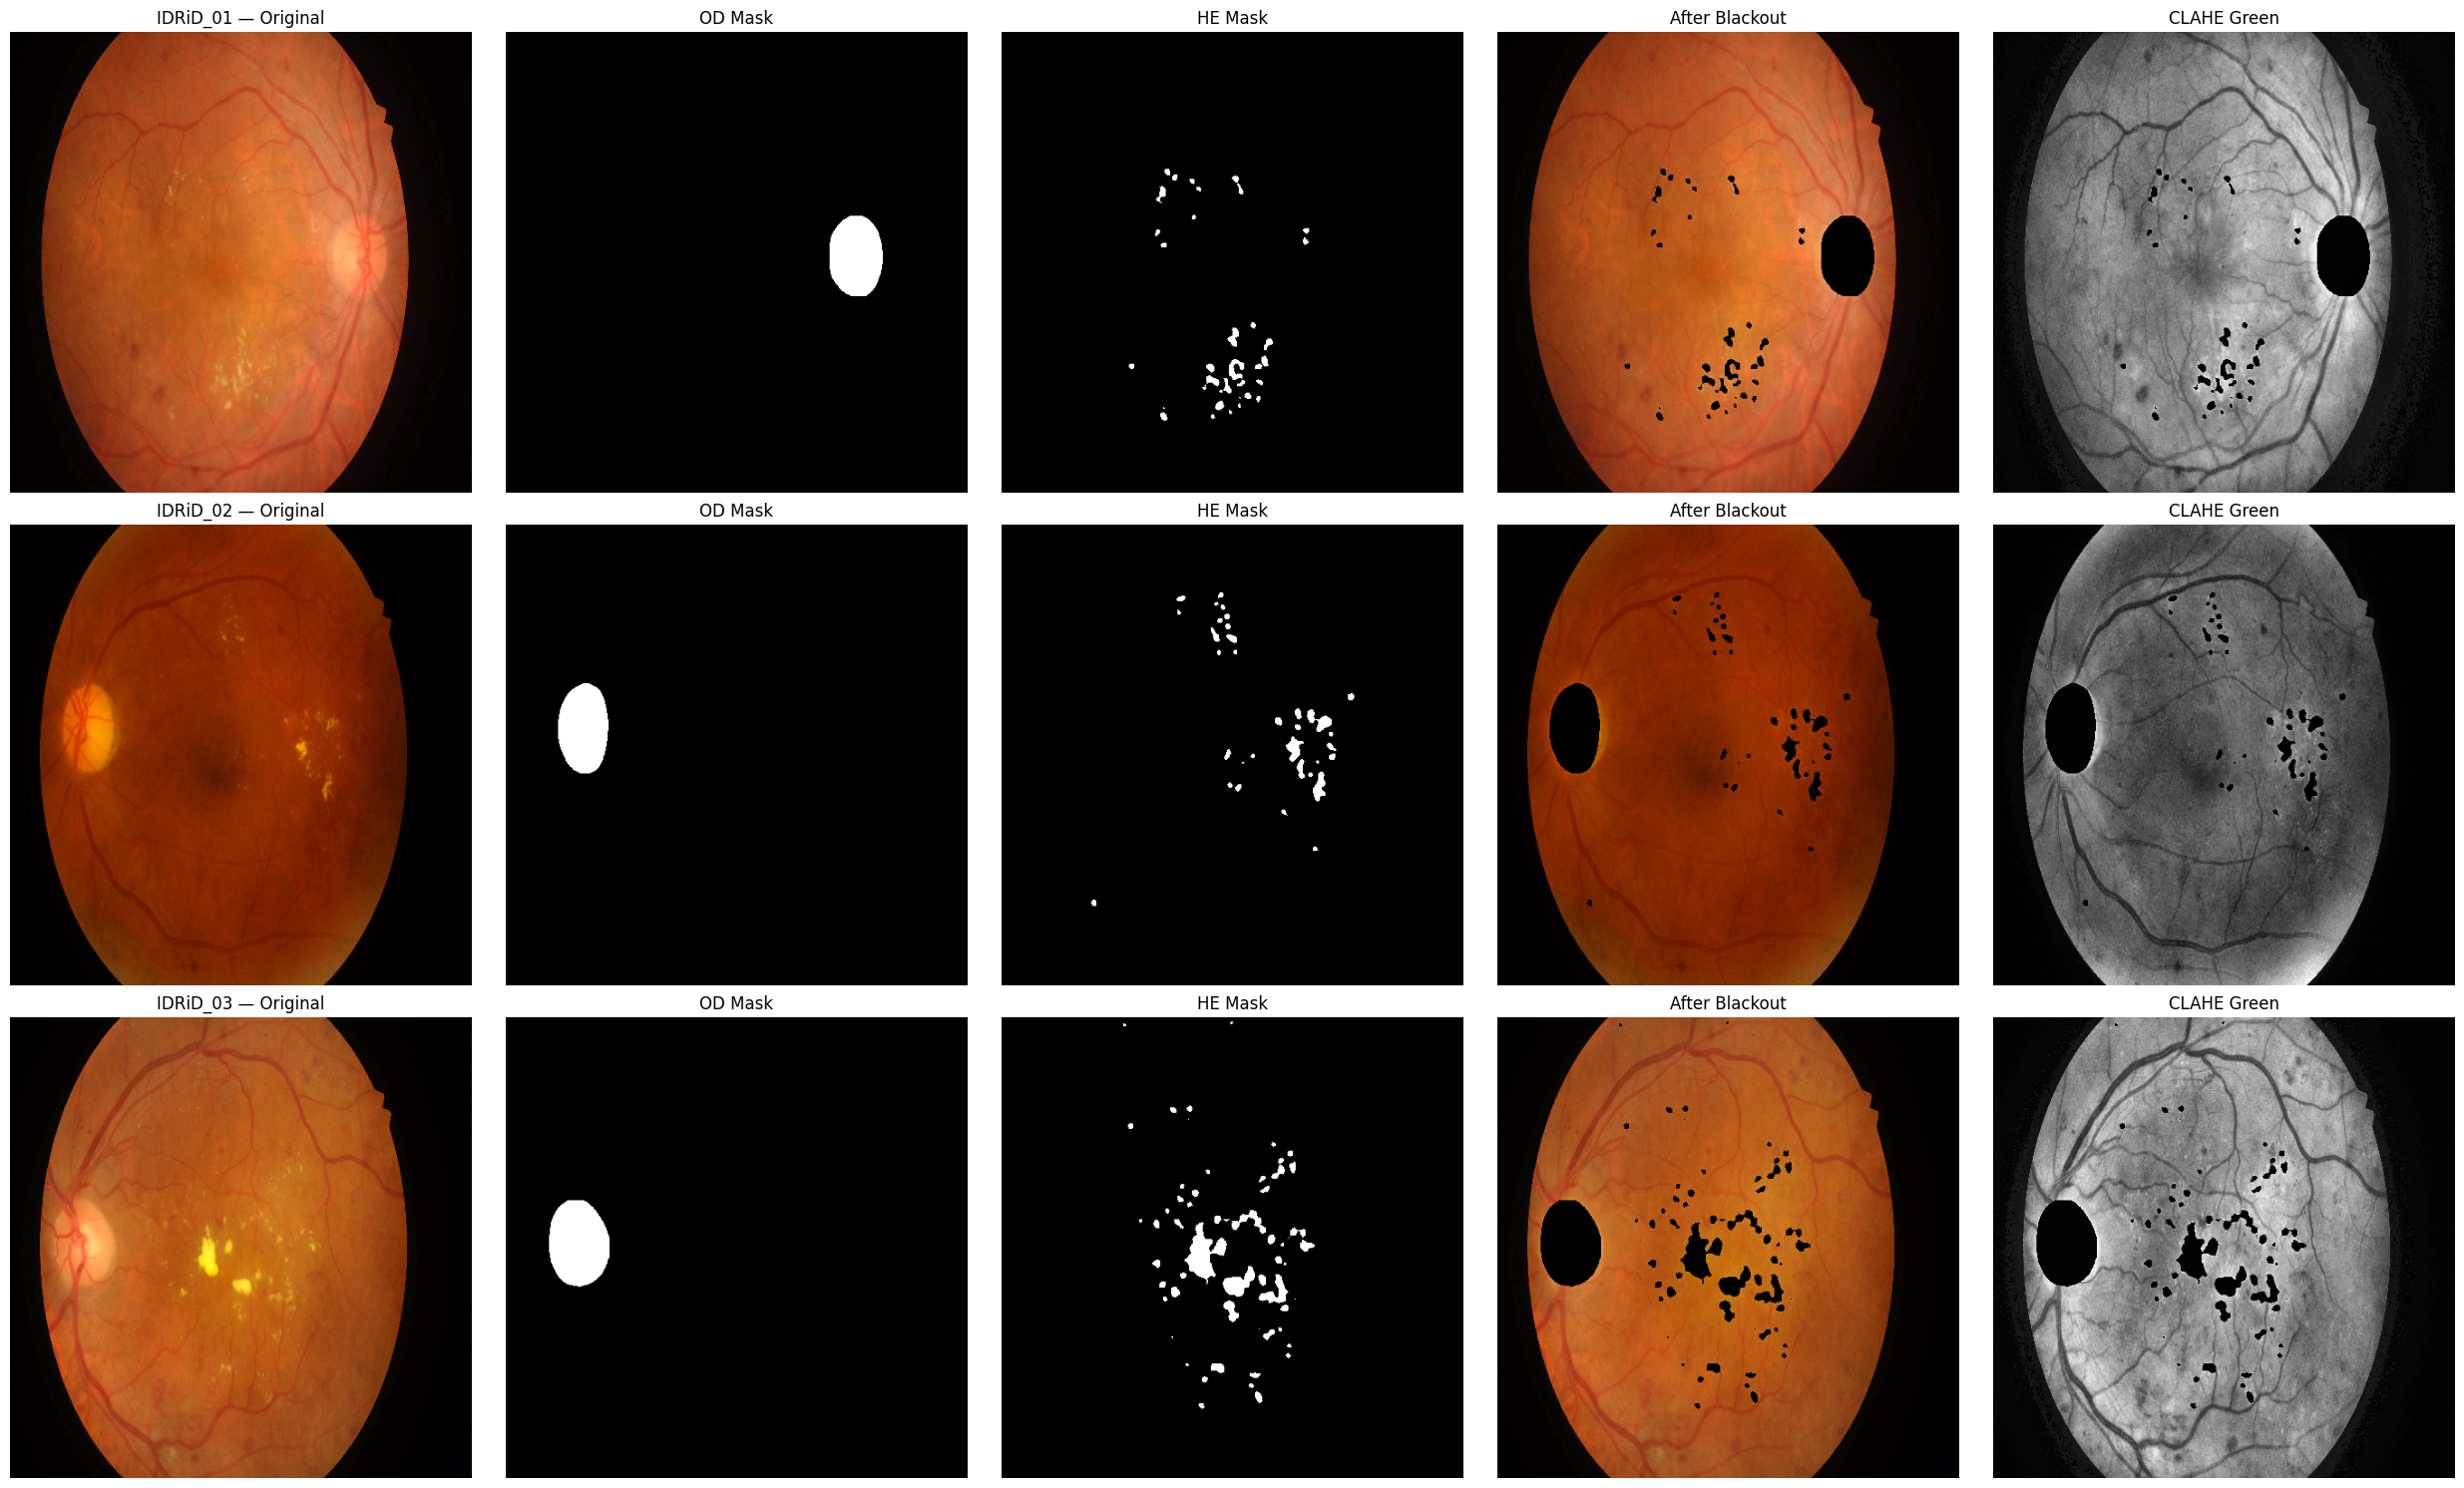

Visualisasi preprocessing OK


In [44]:
# Ambil 3 sample untuk visualisasi preprocessing
sample_images = sorted(ORIG_TRAIN.glob("IDRiD_*.jpg"))[:3]

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
col_titles = ["Original", "OD Mask", "HE Mask", "After Blackout", "CLAHE Green"]

for row, img_path in enumerate(sample_images):
    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))

    preprocessed, od_mask, he_mask = preprocess_image(
        image_rgb, od_model, he_model, IMG_SIZE
    )
    blacked = apply_blackout(resized, od_mask, he_mask)

    axes[row, 0].imshow(resized)
    axes[row, 0].set_title(f"{img_path.stem} — {col_titles[0]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(od_mask, cmap="gray")
    axes[row, 1].set_title(col_titles[1])
    axes[row, 1].axis("off")

    axes[row, 2].imshow(he_mask, cmap="gray")
    axes[row, 2].set_title(col_titles[2])
    axes[row, 2].axis("off")

    axes[row, 3].imshow(blacked)
    axes[row, 3].set_title(col_titles[3])
    axes[row, 3].axis("off")

    axes[row, 4].imshow(preprocessed[:, :, 0], cmap="gray")
    axes[row, 4].set_title(col_titles[4])
    axes[row, 4].axis("off")

plt.tight_layout()
plt.savefig("visualisasi_preprocessing_pipeline.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualisasi preprocessing OK")

## 6. Dataset Class (dengan Preprocessing On-the-fly)

In [45]:
class IDRiDSEDataset(Dataset):
    """
    Dataset untuk Soft Exudate segmentation.
    Preprocessing (blackout OD+HE, CLAHE) dilakukan on-the-fly.
    """

    def __init__(self, img_dir, gt_dir, gt_suffix, od_model, he_model,
                 transform=None, img_size=512, precompute=True):
        self.img_dir = Path(img_dir)
        self.gt_dir = Path(gt_dir)
        self.gt_suffix = gt_suffix
        self.od_model = od_model
        self.he_model = he_model
        self.transform = transform
        self.img_size = img_size

        # Kumpulkan samples
        self.samples = []
        for img_path in sorted(self.img_dir.glob("IDRiD_*.jpg")):
            stem = img_path.stem
            gt_path = self.gt_dir / f"{stem}{self.gt_suffix}"
            self.samples.append({
                "img_path": img_path,
                "gt_path": gt_path if gt_path.exists() else None,
                "stem": stem,
            })

        n_with_gt = sum(1 for s in self.samples if s["gt_path"] is not None)
        print(f"  Dataset: {len(self.samples)} gambar, {n_with_gt} dengan SE GT")

        # Precompute preprocessed images
        self.precomputed = {}
        if precompute:
            print("  Precomputing preprocessing...")
            for i, sample in enumerate(self.samples):
                image = cv2.imread(str(sample["img_path"]))
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                preprocessed, _, _ = preprocess_image(
                    image_rgb, self.od_model, self.he_model, self.img_size
                )
                self.precomputed[i] = preprocessed
                if (i + 1) % 10 == 0:
                    print(f"    {i + 1}/{len(self.samples)} done")
            print(f"  Precomputing done ({len(self.precomputed)} images)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Get preprocessed image
        if idx in self.precomputed:
            image = self.precomputed[idx]
        else:
            raw = cv2.imread(str(sample["img_path"]))
            raw_rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
            image, _, _ = preprocess_image(
                raw_rgb, self.od_model, self.he_model, self.img_size
            )

        # Load SE mask
        if sample["gt_path"] is not None:
            mask = cv2.imread(str(sample["gt_path"]), cv2.IMREAD_UNCHANGED)
            if mask.ndim == 3:
                mask = mask[:, :, :3].max(axis=2)
            mask = (mask > 10).astype(np.float32)
            mask = cv2.resize(mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)
        else:
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)

        # Augmentation
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask)

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

print("Dataset class OK")

Dataset class OK


## 7. Augmentasi

In [46]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=45,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5,
    ),
    A.ElasticTransform(alpha=120, sigma=12, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("Augmentasi OK")

Augmentasi OK


/var/folders/p3/0mc5zsd91bdcw4p37s0rxmf80000gn/T/ipykernel_51758/759778290.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


## 8. Setup DataLoaders

In [47]:
print("[Train set]")
train_dataset = IDRiDSEDataset(
    img_dir=ORIG_TRAIN,
    gt_dir=GT_SE_TRAIN,
    gt_suffix=SE_SUFFIX,
    od_model=od_model,
    he_model=he_model,
    transform=train_transform,
    img_size=IMG_SIZE,
    precompute=True,
)

print("\n[Test set]")
test_dataset = IDRiDSEDataset(
    img_dir=ORIG_TEST,
    gt_dir=GT_SE_TEST,
    gt_suffix=SE_SUFFIX,
    od_model=od_model,
    he_model=he_model,
    transform=test_transform,
    img_size=IMG_SIZE,
    precompute=True,
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

# Sanity check
img, msk = train_dataset[0]
print(f"\nSanity check:")
print(f"  Image shape: {img.shape}, dtype: {img.dtype}")
print(f"  Mask shape : {msk.shape}, dtype: {msk.dtype}")
print(f"  Mask range : [{msk.min():.1f}, {msk.max():.1f}]")

[Train set]
  Dataset: 54 gambar, 26 dengan SE GT
  Precomputing preprocessing...
    10/54 done
    20/54 done
    30/54 done
    40/54 done
    50/54 done
  Precomputing done (54 images)

[Test set]
  Dataset: 27 gambar, 14 dengan SE GT
  Precomputing preprocessing...
    10/27 done
    20/27 done
  Precomputing done (27 images)

Sanity check:
  Image shape: torch.Size([3, 512, 512]), dtype: torch.float32
  Mask shape : torch.Size([1, 512, 512]), dtype: torch.float32
  Mask range : [0.0, 0.0]


## 9. Loss & Metrik

In [48]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.3, dice_weight=0.7, smooth=1.0, pos_weight=10.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.pos_weight_val = pos_weight
        # pos_weight will be moved to correct device in forward()

    def forward(self, logits, targets):
        pw = torch.tensor([self.pos_weight_val], device=logits.device)
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=pw
        )

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice = (2.0 * intersection + self.smooth) / (
            probs_flat.sum() + targets_flat.sum() + self.smooth
        )
        dice_loss = 1.0 - dice

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


def compute_metrics(pred_mask, gt_mask):
    pred = pred_mask.flatten().astype(bool)
    gt = gt_mask.flatten().astype(bool)
    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()
    tn = (~pred & ~gt).sum()
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 1.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 1.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 1.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    return {"iou": float(iou), "sensitivity": float(sensitivity),
            "specificity": float(specificity), "accuracy": float(accuracy)}


criterion = BCEDiceLoss(bce_weight=0.3, dice_weight=0.7, pos_weight=10.0)
print("Loss & metrik OK")

Loss & metrik OK


## 10. Training & Evaluation Functions

In [49]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, dataloader, device, threshold=0.5):
    model.eval()
    all_metrics = []

    for images, masks in dataloader:
        images = images.to(device)
        logits = model(images)
        preds = (torch.sigmoid(logits) > threshold).cpu().numpy().astype(np.uint8)
        gt = masks.cpu().numpy().astype(np.uint8)

        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gt[i])
            all_metrics.append(m)

    avg = {}
    for key in all_metrics[0]:
        avg[key] = np.mean([m[key] for m in all_metrics])
    return avg

print("Training & evaluation functions OK")

Training & evaluation functions OK


## 11. Model: Attention U-Net + Training

In [50]:
# === Model: Attention U-Net ===
se_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse",
)
se_model = se_model.to(DEVICE)

total_params = sum(p.numel() for p in se_model.parameters())
print(f"Model        : Attention U-Net (scse) + ResNet34")
print(f"Total params : {total_params:,}")

# === Hyperparameters ===
NUM_EPOCHS = 150
LR = 1e-4
PATIENCE = 25

# === Optimizer & Scheduler ===
optimizer = torch.optim.AdamW(se_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=7
)

# === Training ===
save_dir = Path("runs/attention_unet_se")
save_dir.mkdir(parents=True, exist_ok=True)

best_iou = 0.0
best_epoch = 0
history = {"train_loss": [], "test_iou": [], "test_sensitivity": [],
           "test_specificity": [], "lr": []}

print(f"\n{'='*70}")
print(f"  TRAINING ATTENTION U-NET untuk Soft Exudate")
print(f"{'='*70}")
print(f"  Encoder      : ResNet34 (ImageNet)")
print(f"  Attention    : scse")
print(f"  Epochs       : {NUM_EPOCHS}")
print(f"  Batch size   : 4")
print(f"  LR           : {LR}")
print(f"  Scheduler    : ReduceLROnPlateau (patience=7)")
print(f"  Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Patience     : {PATIENCE}")
print(f"  Main metric  : IoU")
print(f"  Device       : {DEVICE}")
print()

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(se_model, train_loader, criterion, optimizer, DEVICE)
    metrics = evaluate(se_model, test_loader, DEVICE)

    # Scheduler based on IoU
    scheduler.step(metrics["iou"])
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["test_iou"].append(metrics["iou"])
    history["test_sensitivity"].append(metrics["sensitivity"])
    history["test_specificity"].append(metrics["specificity"])
    history["lr"].append(current_lr)

    elapsed = time.time() - start

    # Save best based on IoU
    marker = ""
    if metrics["iou"] > best_iou:
        best_iou = metrics["iou"]
        best_epoch = epoch
        torch.save(se_model.state_dict(), save_dir / "best.pt")
        marker = " ★ BEST"

    print(
        f"  Epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"IoU: {metrics['iou']:.4f} | "
        f"Sens: {metrics['sensitivity']:.4f} | "
        f"Spec: {metrics['specificity']:.4f} | "
        f"LR: {current_lr:.1e} | "
        f"{elapsed:.1f}s{marker}"
    )

    if epoch - best_epoch >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch} (best was epoch {best_epoch})")
        break

torch.save(se_model.state_dict(), save_dir / "last.pt")
with open(save_dir / "history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"\n  Best IoU: {best_iou:.4f} (epoch {best_epoch})")
print(f"  Model saved to {save_dir}")

Model        : Attention U-Net (scse) + ResNet34
Total params : 24,550,360

  TRAINING ATTENTION U-NET untuk Soft Exudate
  Encoder      : ResNet34 (ImageNet)
  Attention    : scse
  Epochs       : 150
  Batch size   : 4
  LR           : 0.0001
  Scheduler    : ReduceLROnPlateau (patience=7)
  Image size   : 512x512
  Patience     : 25
  Main metric  : IoU
  Device       : mps

  Epoch   1/150 | Loss: 0.8963 | IoU: 0.0033 | Sens: 0.8134 | Spec: 0.6145 | LR: 1.0e-04 | 10.9s ★ BEST
  Epoch   2/150 | Loss: 0.8572 | IoU: 0.0067 | Sens: 0.7382 | Spec: 0.8387 | LR: 1.0e-04 | 9.9s ★ BEST
  Epoch   3/150 | Loss: 0.8286 | IoU: 0.0152 | Sens: 0.7371 | Spec: 0.9595 | LR: 1.0e-04 | 9.9s ★ BEST
  Epoch   4/150 | Loss: 0.8096 | IoU: 0.0181 | Sens: 0.7354 | Spec: 0.9753 | LR: 1.0e-04 | 9.8s ★ BEST
  Epoch   5/150 | Loss: 0.7945 | IoU: 0.0158 | Sens: 0.8702 | Spec: 0.9544 | LR: 1.0e-04 | 10.0s
  Epoch   6/150 | Loss: 0.7827 | IoU: 0.0581 | Sens: 0.7266 | Spec: 0.9924 | LR: 1.0e-04 | 9.8s ★ BEST
  Epoc

## 12. Visualisasi Training History

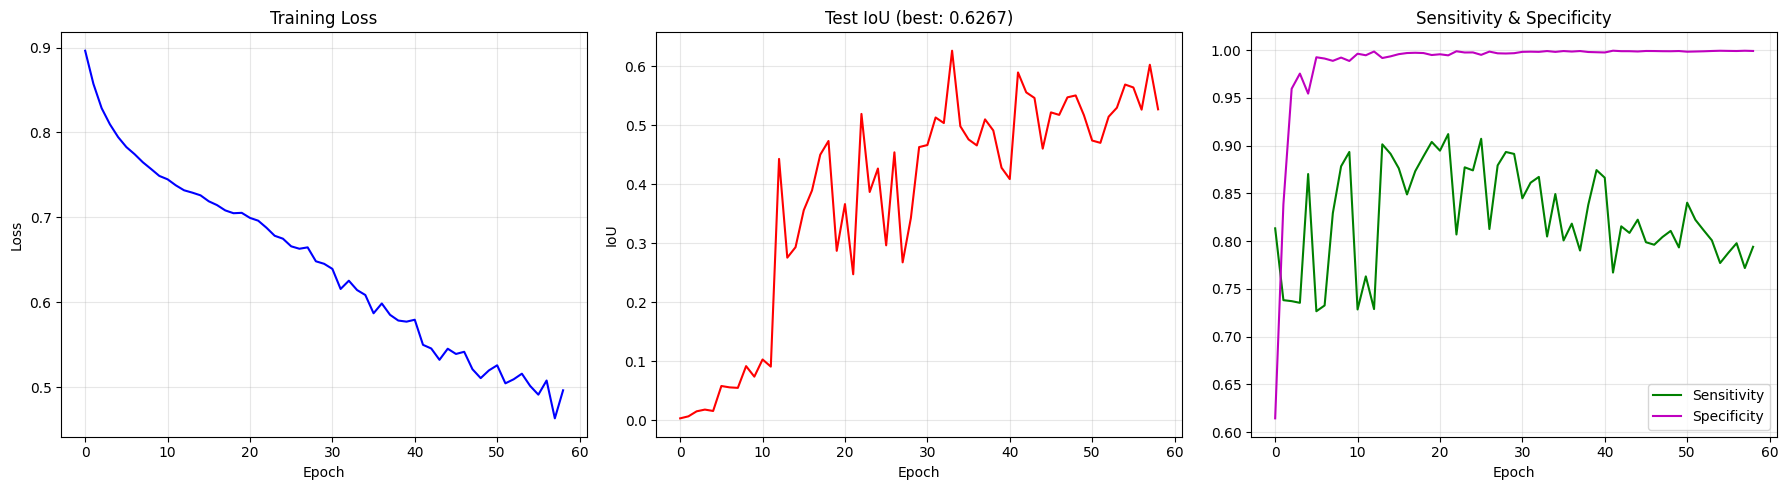

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], "b-")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["test_iou"], "r-")
axes[1].set_title(f"Test IoU (best: {best_iou:.4f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["test_sensitivity"], "g-", label="Sensitivity")
axes[2].plot(history["test_specificity"], "m-", label="Specificity")
axes[2].set_title("Sensitivity & Specificity")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("visualisasi_training_attention_unet_se.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Evaluasi Detail per Gambar

In [52]:
# Load best model
best_se_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse",
)
best_se_model.load_state_dict(
    torch.load("runs/attention_unet_se/best.pt", map_location=DEVICE, weights_only=True)
)
best_se_model = best_se_model.to(DEVICE)
best_se_model.eval()

print(f"{'='*65}")
print(f"  EVALUASI DETAIL: Soft Exudate (Attention U-Net)")
print(f"{'='*65}")

all_metrics = []
with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, gt_mask = test_dataset[idx]
        stem = test_dataset.samples[idx]["stem"]

        logits = best_se_model(img.unsqueeze(0).to(DEVICE))
        pred = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
        gt = gt_mask.squeeze().numpy().astype(np.uint8)

        m = compute_metrics(pred, gt)
        all_metrics.append(m)

        has_gt = "✓" if test_dataset.samples[idx]["gt_path"] is not None else "✗"
        print(f"  {stem} [{has_gt}]: IoU={m['iou']:.4f} | Sens={m['sensitivity']:.4f} | Spec={m['specificity']:.4f}")

avg_iou  = np.mean([m["iou"] for m in all_metrics])
avg_sens = np.mean([m["sensitivity"] for m in all_metrics])
avg_spec = np.mean([m["specificity"] for m in all_metrics])
avg_acc  = np.mean([m["accuracy"] for m in all_metrics])

print(f"\n  Average IoU         : {avg_iou:.4f}")
print(f"  Average Sensitivity : {avg_sens:.4f}")
print(f"  Average Specificity : {avg_spec:.4f}")
print(f"  Average Accuracy    : {avg_acc:.4f}")

  EVALUASI DETAIL: Soft Exudate (Attention U-Net)
  IDRiD_55 [✓]: IoU=0.0000 | Sens=0.0000 | Spec=1.0000
  IDRiD_56 [✓]: IoU=0.4554 | Sens=0.7888 | Spec=0.9965
  IDRiD_57 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_58 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_59 [✓]: IoU=0.6465 | Sens=0.8468 | Spec=0.9955
  IDRiD_60 [✓]: IoU=0.4886 | Sens=0.7325 | Spec=0.9967
  IDRiD_61 [✓]: IoU=0.3906 | Sens=0.9816 | Spec=0.9978
  IDRiD_62 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_63 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_64 [✓]: IoU=0.6911 | Sens=0.8707 | Spec=0.9991
  IDRiD_65 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_66 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_67 [✓]: IoU=0.3386 | Sens=0.4388 | Spec=0.9991
  IDRiD_68 [✓]: IoU=0.5206 | Sens=0.7556 | Spec=0.9975
  IDRiD_69 [✗]: IoU=1.0000 | Sens=1.0000 | Spec=1.0000
  IDRiD_70 [✓]: IoU=0.7808 | Sens=0.9269 | Spec=0.9997
  IDRiD_71 [✓]: IoU=0.0000 | Sens=0.0000 | Spec=0.9983
  IDRiD_72 [✓]:

## 14. Visualisasi Prediksi (Full Pipeline)

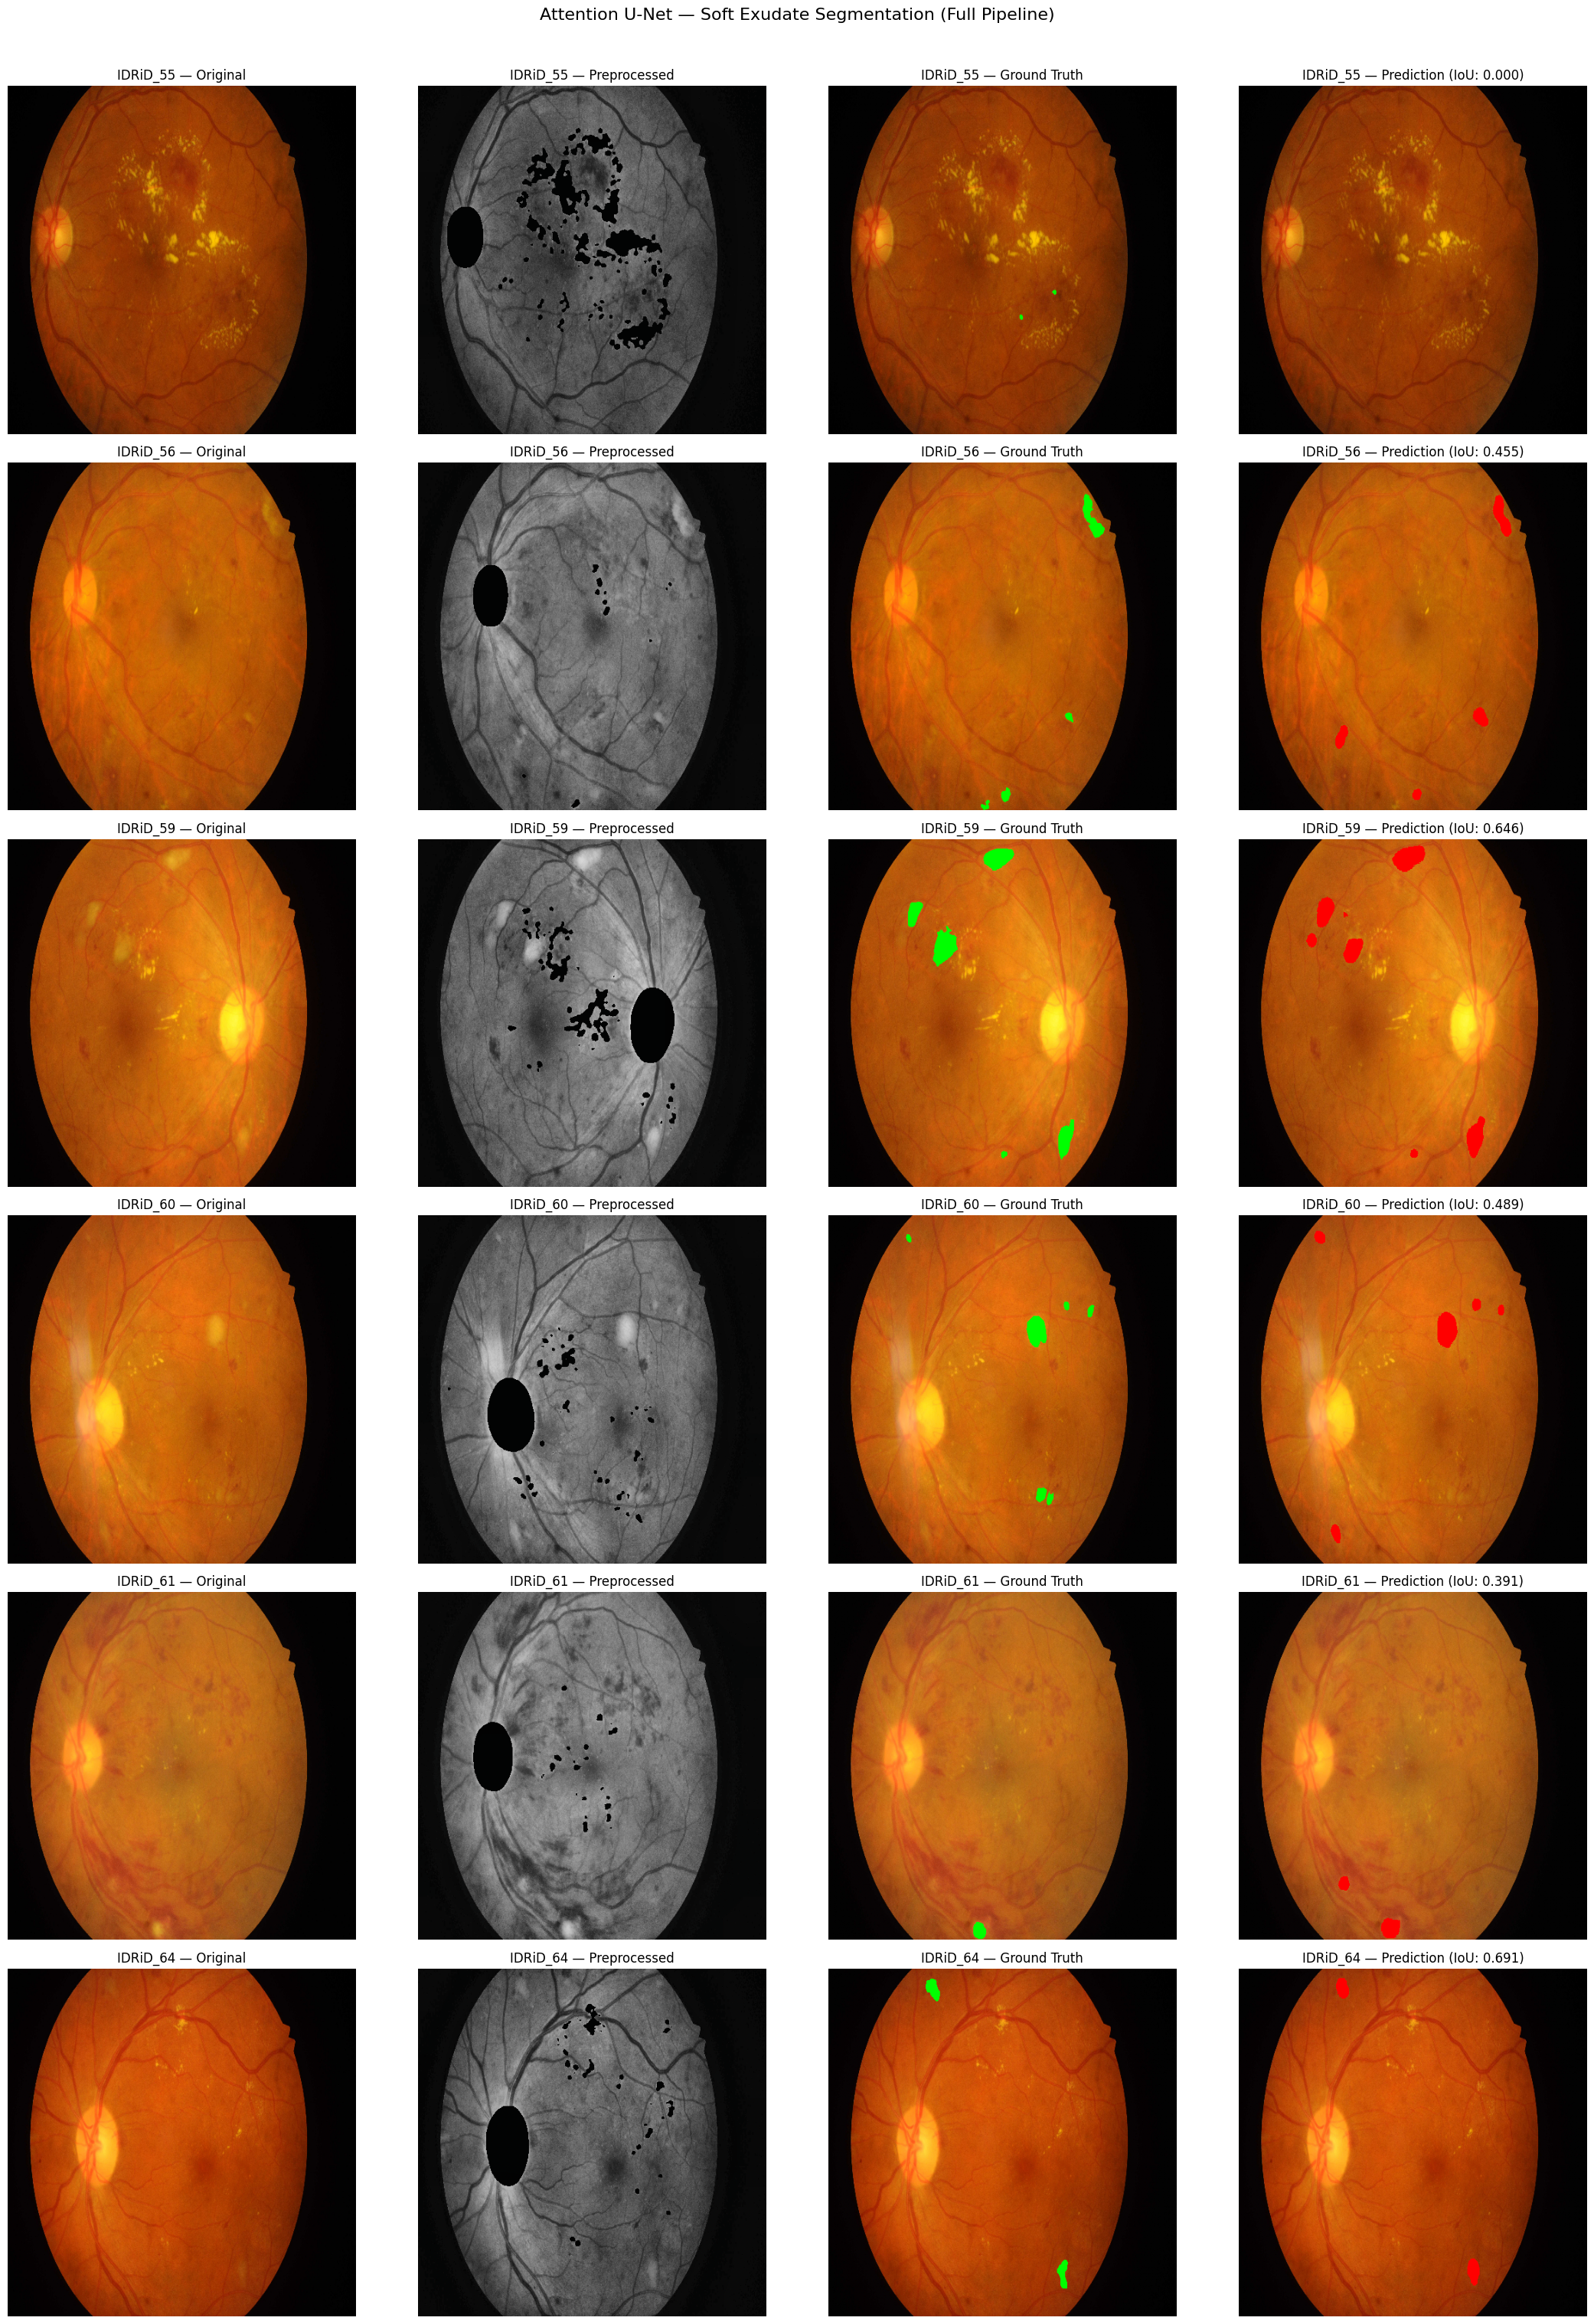

Visualisasi disimpan


In [53]:
# Ambil gambar yang punya SE GT
sample_indices = [
    i for i, s in enumerate(test_dataset.samples)
    if s["gt_path"] is not None
][:6]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(22, 5 * len(sample_indices)))

with torch.no_grad():
    for row, idx in enumerate(sample_indices):
        sample = test_dataset.samples[idx]
        stem = sample["stem"]

        # Load original image
        orig = cv2.imread(str(sample["img_path"]))
        orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        orig_resized = cv2.resize(orig_rgb, (IMG_SIZE, IMG_SIZE))

        # Get preprocessed & predict
        img_tensor, gt_mask = test_dataset[idx]
        logits = best_se_model(img_tensor.unsqueeze(0).to(DEVICE))
        pred_mask = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
        gt_np = gt_mask.squeeze().numpy().astype(np.uint8)

        # Preprocessed image (denormalize)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)

        m = compute_metrics(pred_mask, gt_np)

        # Col 0: Original
        axes[row, 0].imshow(orig_resized)
        axes[row, 0].set_title(f"{stem} — Original")
        axes[row, 0].axis("off")

        # Col 1: Preprocessed (after blackout + CLAHE)
        axes[row, 1].imshow(img_np)
        axes[row, 1].set_title(f"{stem} — Preprocessed")
        axes[row, 1].axis("off")

        # Col 2: GT overlay
        gt_overlay = (orig_resized / 255.0).copy()
        gt_overlay[gt_np > 0] = [0, 1, 0]
        axes[row, 2].imshow(gt_overlay)
        axes[row, 2].set_title(f"{stem} — Ground Truth")
        axes[row, 2].axis("off")

        # Col 3: Prediction overlay
        pred_overlay = (orig_resized / 255.0).copy()
        pred_overlay[pred_mask > 0] = [1, 0, 0]
        axes[row, 3].imshow(pred_overlay)
        axes[row, 3].set_title(f"{stem} — Prediction (IoU: {m['iou']:.3f})")
        axes[row, 3].axis("off")

plt.suptitle("Attention U-Net — Soft Exudate Segmentation (Full Pipeline)", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("visualisasi_prediksi_se_full_pipeline.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan")

## 15. Ringkasan Keseluruhan Pipeline

In [54]:
print("="*70)
print("  RINGKASAN KESELURUHAN PIPELINE")
print("="*70)
print()
print("  ┌──────────────────────────────────────────────────────────────┐")
print("  │  STAGE 1: Segmentasi OD & HE                                │")
print("  │                                                              │")
print("  │  Model A: Mask R-CNN + ResNet50 → Optic Disc                │")
print(f"  │           IoU: 0.9453 (baseline: 0.843)                     │")
print("  │                                                              │")
print("  │  Model B: U-Net + ResNet34 → Hard Exudate                   │")
print(f"  │           IoU: 0.3640 | Sens: 0.67 (baseline sens: 0.454)  │")
print("  │                                                              │")
print("  ├──────────────────────────────────────────────────────────────┤")
print("  │  STAGE 2: Preprocessing                                     │")
print("  │  Raw → Blackout OD & HE (predicted) → CLAHE Green Channel   │")
print("  │                                                              │")
print("  ├──────────────────────────────────────────────────────────────┤")
print("  │  STAGE 3: Segmentasi Soft Exudate                           │")
print("  │                                                              │")
print("  │  Model C: Attention U-Net (scse) + ResNet34                 │")
print(f"  │           IoU:         {avg_iou:.4f}                              │")
print(f"  │           Sensitivity: {avg_sens:.4f}                              │")
print(f"  │           Specificity: {avg_spec:.4f}                              │")
print(f"  │           Accuracy:    {avg_acc:.4f}                              │")
print("  │                                                              │")
print("  └──────────────────────────────────────────────────────────────┘")
print()
print("  Model weights:")
print("    - OD: runs/mask_rcnn_od/best.pt")
print("    - HE: runs/unet_he/best.pt")
print("    - SE: runs/attention_unet_se/best.pt")

  RINGKASAN KESELURUHAN PIPELINE

  ┌──────────────────────────────────────────────────────────────┐
  │  STAGE 1: Segmentasi OD & HE                                │
  │                                                              │
  │  Model A: Mask R-CNN + ResNet50 → Optic Disc                │
  │           IoU: 0.9453 (baseline: 0.843)                     │
  │                                                              │
  │  Model B: U-Net + ResNet34 → Hard Exudate                   │
  │           IoU: 0.3640 | Sens: 0.67 (baseline sens: 0.454)  │
  │                                                              │
  ├──────────────────────────────────────────────────────────────┤
  │  STAGE 2: Preprocessing                                     │
  │  Raw → Blackout OD & HE (predicted) → CLAHE Green Channel   │
  │                                                              │
  ├──────────────────────────────────────────────────────────────┤
  │  STAGE 3: Segmentasi Soft Exudat